In [1]:
import pandas as pd
df = pd.read_parquet("/Users/costanzastassi/Desktop/mgt-stylometry/data/raw/hc3_flat.parquet")
print(df.shape)
print(df.groupby(["domain", "label"]).size())
qid = df["question_id"].iloc[0]
for _, r in df[df["question_id"] == qid].iterrows():
    print("=== UMANO" if r["label"] == 0 else "=== MACCHINA")
    print(r["text"][:500])
print(df["question_id"].head(10).tolist())
print(df["question_id"].nunique(), "id unici su", len(df), "righe")
coppia = df.iloc[0:2]
for _, r in coppia.iterrows():
    print("=== UMANO" if r["label"] == 0 else "=== MACCHINA")
    print(r["text"][:600])
    print()
    

(47730, 5)
domain       label
finance      0         3933
             1         3933
medicine     0         1246
             1         1246
open_qa      0         1187
             1         1187
reddit_eli5  0        16657
             1        16657
wiki_csai    0          842
             1          842
dtype: int64
=== UMANO
Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won the " Best film " , but even if you won the best director or best script , you 're still an " oscar - winning " film . Same thing for best sellers . Also , IIRC the rankings change every week or something like that . Some you might not be best seller one week , but you may be the next week . I gues
=== MACCHINA
There are many different best seller lists that are published by various organizations, and the New York Times is just one of them. The New York Times be

In [2]:
import pandas as pd
df = pd.read_parquet("/Users/costanzastassi/Desktop/mgt-stylometry/data/processed/hc3_clean.parquet")
print(df.shape)
print(df.groupby(["domain", "label"]).size())
qid = df["question_id"].iloc[0]
for _, r in df[df["question_id"] == qid].iterrows():
    print("=== UMANO" if r["label"] == 0 else "=== MACCHINA")
    print(r["text"][:500])
print(df["question_id"].head(10).tolist())
print(df["question_id"].nunique(), "id unici su", len(df), "righe")
coppia = df.iloc[0:2]
for _, r in coppia.iterrows():
    print("=== UMANO" if r["label"] == 0 else "=== MACCHINA")
    print(r["text"][:600])
    print()
    

(19980, 6)
domain       label
finance      0        2029
             1        2029
medicine     0         439
             1         439
reddit_eli5  0        6984
             1        6984
wiki_csai    0         538
             1         538
dtype: int64
=== UMANO
I know this question has a lot of answers already, but I feel the answers are phrased either strongly against, or mildly for, co-signing. What it amounts down to is that this is a personal choice. You cannot receive reliable information as to whether or not co-signing this loan is a good move due to lack of information. The person involved is going to know the person they would be co-signing for, and the people on this site will only have their own personal preferences of experiences to draw fro
=== MACCHINA
Co-signing a personal loan for a friend or family member can be a risky proposition. When you co-sign a loan, you are agreeing to be responsible for the loan if the borrower is unable to make the payments. This means 

In [3]:
grezzo = pd.read_parquet("/Users/costanzastassi/Desktop/mgt-stylometry/data/raw/hc3_flat.parquet")

grezzo["n_parole"] = grezzo["text"].str.split().str.len()
print(grezzo.groupby(["domain", "label"])["n_parole"].describe()[["25%", "50%", "75%"]])

                     25%    50%     75%
domain      label                      
finance     0       71.0  129.0  228.00
            1      169.0  206.0  245.00
medicine    0       51.0   74.0  103.00
            1      153.0  185.0  219.00
open_qa     0       20.0   27.0   38.00
            1       78.0  104.0  153.00
reddit_eli5 0       49.0   95.0  184.00
            1      137.0  173.0  208.00
wiki_csai   0       98.0  166.0  273.25
            1      156.0  187.5  216.00


# Fase 3 — Analisi esplorativa

Progetto: Riconoscere la mano della macchina (traccia 20).

Obiettivo di questo notebook: caratterizzare il corpus **prima** di
estrarre feature e addestrare modelli. Serve a due cose: capire con che
dati si ha a che fare, e produrre le figure per la presentazione.

## 0. Setup

In [4]:
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RADICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURE = RADICE / "results" / "figures"
TABELLE = RADICE / "results" / "tables"
FIGURE.mkdir(parents=True, exist_ok=True)
TABELLE.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

ETICHETTE = {0: "umano", 1: "macchina"}
COLORI = {0: "#4C72B0", 1: "#DD8452"}

print("Radice:", RADICE)

Matplotlib is building the font cache; this may take a moment.


Radice: /Users/costanzastassi/Desktop/mgt-stylometry


In [5]:
grezzo = pd.read_parquet(RADICE / "data" / "raw" / "hc3_flat.parquet")
pulito = pd.read_parquet(RADICE / "data" / "processed" / "hc3_clean.parquet")

print(f"Grezzo: {grezzo.shape[0]} righe, {grezzo['question_id'].nunique()} coppie")
print(f"Pulito: {pulito.shape[0]} righe, {pulito['question_id'].nunique()} coppie")
print(f"Ritenzione: {pulito.shape[0] / grezzo.shape[0]:.1%}")

Grezzo: 47730 righe, 23865 coppie
Pulito: 19980 righe, 9990 coppie
Ritenzione: 41.9%


## 1. Composizione del corpus

Due domande: le classi sono bilanciate? e come si distribuiscono i domini?

La seconda conta perche' HC3 e' fortemente sbilanciato verso reddit_eli5.
Se un dominio domina, il modello impara soprattutto il registro di quel
dominio, non la generazione automatica in generale.

In [6]:
conteggi = (
    pulito.groupby(["domain", "label"])
    .size()
    .unstack()
    .rename(columns=ETICHETTE)
)
conteggi["totale"] = conteggi.sum(axis=1)
conteggi["quota"] = conteggi["totale"] / conteggi["totale"].sum()
conteggi = conteggi.sort_values("totale", ascending=False)
conteggi

label,umano,macchina,totale,quota
domain,,,,
reddit_eli5,6984,6984,13968,0.699099
finance,2029,2029,4058,0.203103
wiki_csai,538,538,1076,0.053854
medicine,439,439,878,0.043944


In [7]:
# Confronto con il grezzo: quali domini ha penalizzato il filtro?
quota_grezzo = grezzo.groupby("domain").size() / len(grezzo)
quota_pulito = pulito.groupby("domain").size() / len(pulito)

confronto_domini = pd.DataFrame({
    "quota_grezzo": quota_grezzo,
    "quota_pulito": quota_pulito,
    "n_grezzo": grezzo.groupby("domain").size(),
    "n_pulito": pulito.groupby("domain").size(),
})
confronto_domini["ritenzione"] = confronto_domini["n_pulito"] / confronto_domini["n_grezzo"]
confronto_domini = confronto_domini.sort_values("n_pulito", ascending=False)
confronto_domini.to_csv(TABELLE / "composizione_domini.csv")
confronto_domini

,quota_grezzo,quota_pulito,n_grezzo,n_pulito,ritenzione
domain,,,,,
reddit_eli5,0.697968,0.699099,33314,13968.0,0.419283
finance,0.164802,0.203103,7866,4058.0,0.515891
wiki_csai,0.035282,0.053854,1684,1076.0,0.638955
medicine,0.052210,0.043944,2492,878.0,0.352327
open_qa,0.049738,NaN,2374,NaN,NaN


**Da annotare per il README**: se la ritenzione varia molto tra domini,
il filtro di lunghezza non e' neutro rispetto al dominio. Va dichiarato
come limite.

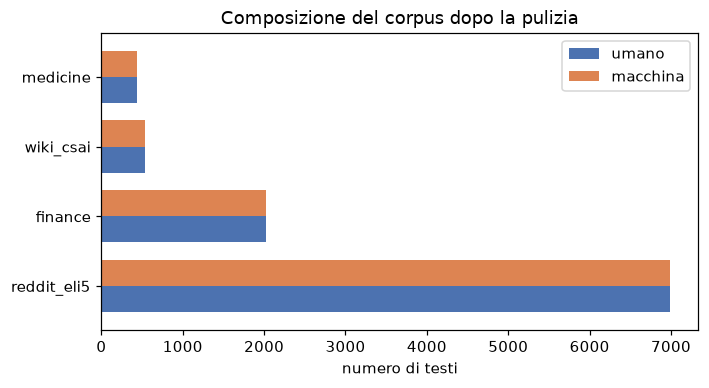

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
conteggi[["umano", "macchina"]].plot(
    kind="barh", ax=ax, color=[COLORI[0], COLORI[1]], width=0.75
)
ax.set_xlabel("numero di testi")
ax.set_ylabel("")
ax.set_title("Composizione del corpus dopo la pulizia")
ax.legend(title=None)
fig.savefig(FIGURE / "01_composizione_domini.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Lunghezza dei testi

L'appaiamento per lunghezza (tolleranza 0.50) serve a impedire che il
classificatore impari semplicemente "lungo = macchina". Qui si verifica
se ha funzionato.

In [9]:
for df in (grezzo, pulito):
    df["n_parole"] = df["text"].str.split().str.len()

riepilogo = pd.concat([
    grezzo.groupby("label")["n_parole"].describe().assign(fase="grezzo"),
    pulito.groupby("label")["n_parole"].describe().assign(fase="pulito"),
])
riepilogo.index = riepilogo.index.map(ETICHETTE)
riepilogo[["fase", "count", "mean", "50%", "std", "min", "max"]]

,fase,count,mean,50%,std,min,max
label,,,,,,,
umano,grezzo,23865.0,147.985586,94.0,176.561689,1.0,7904.0
macchina,grezzo,23865.0,178.008799,177.0,58.364430,1.0,639.0
umano,pulito,9990.0,172.748248,150.0,85.545472,50.0,595.0
macchina,pulito,9990.0,180.005405,178.0,54.773332,50.0,554.0


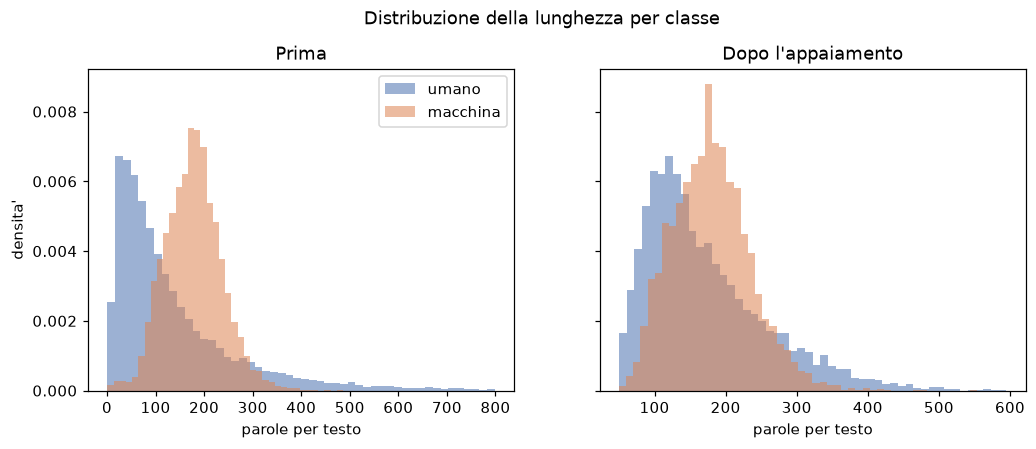

In [10]:
fig, assi = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

for ax, (df, titolo) in zip(assi, [(grezzo, "Prima"), (pulito, "Dopo l'appaiamento")]):
    for etichetta in (0, 1):
        sub = df[df["label"] == etichetta]["n_parole"]
        sub = sub[sub <= 800]
        ax.hist(sub, bins=50, alpha=0.55, label=ETICHETTE[etichetta],
                color=COLORI[etichetta], density=True)
    ax.set_title(titolo)
    ax.set_xlabel("parole per testo")

assi[0].set_ylabel("densita'")
assi[0].legend()
fig.suptitle("Distribuzione della lunghezza per classe", y=1.02)
fig.savefig(FIGURE / "02_lunghezze.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Quanto si sovrappongono le distribuzioni? Se la differenza tra le mediane
# resta grande, la lunghezza e' ancora un predittore forte.
for nome, df in [("grezzo", grezzo), ("pulito", pulito)]:
    m_umano = df[df["label"] == 0]["n_parole"].median()
    m_macchina = df[df["label"] == 1]["n_parole"].median()
    print(f"{nome:8s} mediana umano={m_umano:6.1f}  macchina={m_macchina:6.1f}  "
          f"rapporto={m_macchina / m_umano:.2f}")

grezzo   mediana umano=  94.0  macchina= 177.0  rapporto=1.88
pulito   mediana umano= 150.0  macchina= 178.0  rapporto=1.19


## 3. Numero di frasi

Segmentazione approssimata sulla punteggiatura forte. Non e' precisa quanto
spaCy, ma per l'esplorazione basta ed e' istantanea.

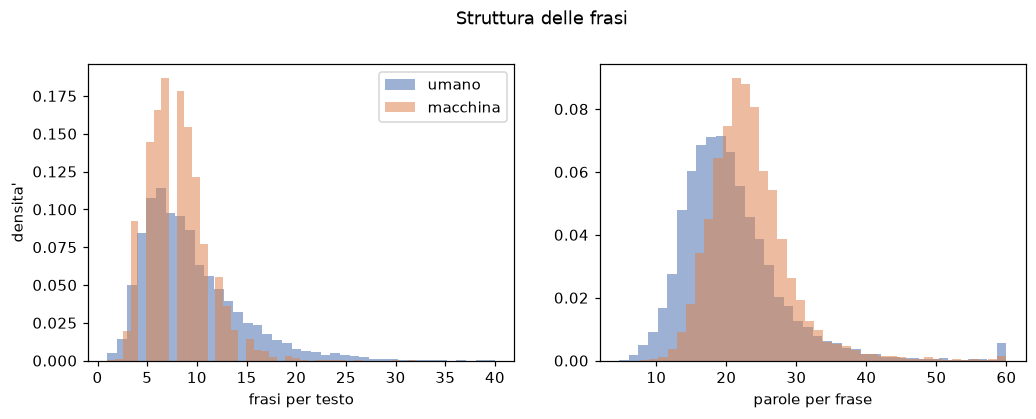

,n_frasi,parole_per_frase
label,,
umano,8.0,19.500000
macchina,8.0,22.666667


In [12]:
import re
RE_FINE_FRASE = re.compile(r"[.!?]+(?:\s|$)")

pulito["n_frasi"] = pulito["text"].map(lambda t: max(1, len(RE_FINE_FRASE.findall(t))))
pulito["parole_per_frase"] = pulito["n_parole"] / pulito["n_frasi"]

fig, assi = plt.subplots(1, 2, figsize=(11, 3.5))

for etichetta in (0, 1):
    sub = pulito[pulito["label"] == etichetta]
    assi[0].hist(sub["n_frasi"].clip(upper=40), bins=40, alpha=0.55,
                 label=ETICHETTE[etichetta], color=COLORI[etichetta], density=True)
    assi[1].hist(sub["parole_per_frase"].clip(upper=60), bins=40, alpha=0.55,
                 label=ETICHETTE[etichetta], color=COLORI[etichetta], density=True)

assi[0].set_xlabel("frasi per testo")
assi[1].set_xlabel("parole per frase")
assi[0].set_ylabel("densita'")
assi[0].legend()
fig.suptitle("Struttura delle frasi", y=1.02)
fig.savefig(FIGURE / "03_frasi.png", dpi=150, bbox_inches="tight")
plt.show()

pulito.groupby("label")[["n_frasi", "parole_per_frase"]].median().rename(index=ETICHETTE)

## 4. Lessico

Venti token piu' frequenti per classe, escluse le stopword. Attenzione:
questa e' un'analisi *lessicale*, mentre il progetto usa feature
*stilometriche*. Serve a farsi un'idea, non e' materiale per il modello
principale — la differenza tra i due approcci e' proprio uno dei confronti
della Fase 5.

In [13]:
STOPWORD = {
    "the", "a", "an", "and", "or", "but", "if", "of", "to", "in", "on", "at",
    "for", "with", "as", "by", "from", "is", "are", "was", "were", "be", "been",
    "being", "it", "its", "this", "that", "these", "those", "i", "you", "he",
    "she", "we", "they", "them", "his", "her", "their", "our", "my", "your",
    "not", "no", "so", "than", "then", "there", "here", "what", "which", "who",
    "have", "has", "had", "do", "does", "did", "can", "could", "will", "would",
    "s", "t", "re", "ve", "ll", "m", "d", "about", "into", "out", "up", "down",
}

def token_frequenti(testi, n=20):
    contatore = Counter()
    for t in testi:
        parole = re.findall(r"[a-z']+", t.lower())
        contatore.update(p for p in parole if p not in STOPWORD and len(p) > 2)
    return contatore.most_common(n)

top_umano = token_frequenti(pulito[pulito["label"] == 0]["text"])
top_macchina = token_frequenti(pulito[pulito["label"] == 1]["text"])

pd.DataFrame({
    "umano": [f"{p} ({n})" for p, n in top_umano],
    "macchina": [f"{p} ({n})" for p, n in top_macchina],
})

,umano,macchina
0,more (6343),may (8702)
1,all (5189),other (7677)
2,when (5136),more (7123)
3,like (5070),people (6812)
4,it's (4836),also (6573)
5,one (4734),when (6345)
6,some (4494),because (6305)
7,people (4435),important (5908)
8,other (4426),it's (5723)
9,because (4278),some (5185)


In [14]:
# Token piu' sbilanciati: quelli che compaiono in una classe e quasi
# per nulla nell'altra. Sono i candidati a diventare "spie" lessicali.
c_umano = Counter()
c_macchina = Counter()
for t in pulito[pulito["label"] == 0]["text"]:
    c_umano.update(set(re.findall(r"[a-z']+", t.lower())))
for t in pulito[pulito["label"] == 1]["text"]:
    c_macchina.update(set(re.findall(r"[a-z']+", t.lower())))

n_um = (pulito["label"] == 0).sum()
n_ma = (pulito["label"] == 1).sum()

righe = []
for parola in set(c_umano) | set(c_macchina):
    du = c_umano.get(parola, 0) / n_um
    dm = c_macchina.get(parola, 0) / n_ma
    if max(du, dm) > 0.02:
        righe.append({"parola": parola, "doc_freq_umano": du,
                      "doc_freq_macchina": dm, "delta": dm - du})

sbilanciati = pd.DataFrame(righe).sort_values("delta")
sbilanciati.to_csv(TABELLE / "token_sbilanciati.csv", index=False)

print("Piu' tipici del testo umano:")
display(sbilanciati.head(12))
print("Piu' tipici del testo generato:")
display(sbilanciati.tail(12).iloc[::-1])

Piu' tipici del testo umano:


,parola,doc_freq_umano,doc_freq_macchina,delta
527,i,0.376677,0.081181,-0.295495
593,but,0.532332,0.281882,-0.250450
474,so,0.476076,0.278178,-0.197898
782,you,0.656857,0.464765,-0.192092
899,just,0.286186,0.115516,-0.170671
501,would,0.284585,0.120821,-0.163764
237,what,0.283383,0.126527,-0.156857
395,all,0.344044,0.187788,-0.156256
379,then,0.251451,0.097197,-0.154254
375,at,0.402803,0.254855,-0.147948


Piu' tipici del testo generato:


,parola,doc_freq_umano,doc_freq_macchina,delta
575,important,0.059059,0.413213,0.354154
775,may,0.165065,0.394595,0.229530
851,such,0.134334,0.342743,0.208408
161,can,0.517718,0.716016,0.198298
85,also,0.286787,0.481582,0.194795
879,or,0.553253,0.747347,0.194094
327,help,0.067467,0.254154,0.186687
141,other,0.319119,0.484084,0.164965
767,including,0.032833,0.183383,0.150551
305,overall,0.014915,0.141041,0.126126


## 5. Esempi appaiati

Lettura diretta di tre coppie. Questo passaggio non produce numeri ma e'
il piu' importante del notebook: serve a formarsi un'intuizione su cosa
distingue le classi **prima** di misurarla, cosi' da poter dire in Fase 6
se i coefficienti del modello confermano o smentiscono la lettura.

In [15]:
def mostra_coppia(qid, larghezza=95):
    coppia = pulito[pulito["question_id"] == qid].sort_values("label")
    domanda = coppia["question"].iloc[0]
    print("=" * larghezza)
    print("DOMANDA:", domanda[:300])
    print("DOMINIO:", coppia["domain"].iloc[0])
    print("=" * larghezza)
    for _, r in coppia.iterrows():
        print(f"\n--- {ETICHETTE[r['label']].upper()} "
              f"({r['n_parole']} parole, {r['n_frasi']} frasi)\n")
        testo = r["text"]
        for i in range(0, len(testo), larghezza):
            print(testo[i:i + larghezza])
    print()

campione = (
    pulito.drop_duplicates("question_id")
    .sample(3, random_state=42)["question_id"]
    .tolist()
)
for qid in campione:
    mostra_coppia(qid)

DOMANDA: Why are solid state drives so much faster than regular hard drives ? and how exactly do they work ? Please explain like I'm five.
DOMINIO: reddit_eli5

--- UMANO (87 parole, 3 frasi)

Imagine you are cooking a pizza and you need the dough, some sauce, and some cheese and they ar
e all located at in different places in a very big kitchen. You could either have Usain Bolt ru
n to each of the places and grab them for you (spinning disk drive) or you could have Tom Brady
, Peyton Manning, and Aaron Rodgers standing next to each of them and they throw them to you at
 the same time (solid state). Usain Bolt is fast but not that fast.

--- MACCHINA (170 parole, 9 frasi)

Solid state drives (SSDs) are faster than regular hard drives because they use memory chips to 
store data, which allows them to access and transfer files much more quickly. Regular hard driv
es, on the other hand, use spinning disks to store data, which makes them slower at accessing a
nd transferring files. Imagine

**Da annotare**: quali differenze si notano a occhio? Candidati tipici —
struttura a paragrafo unico contro elenco, presenza di prima persona e
aneddoti, formule di apertura ricorrenti, connettivi espliciti, chiusure
riassuntive. Scrivere qui le osservazioni e confrontarle in Fase 6 con i
coefficienti del modello.

In [16]:
# Spazio per le osservazioni qualitative.
osservazioni = """
1.inizia con certo (si vede tra l'altro l'indentazione)
2. quello scritto dall'utente parte da più lontano ed è più scenico
3. non da info sui farmaci
"""
print(osservazioni)


1.inizia con certo (si vede tra l'altro l'indentazione)
2. quello scritto dall'utente parte da più lontano ed è più scenico
3. non da info sui farmaci



## 6. Riepilogo

Numeri da riportare nel README e nella slide 2.

In [17]:
riepilogo_finale = {
    "coppie_iniziali": grezzo["question_id"].nunique(),
    "coppie_finali": pulito["question_id"].nunique(),
    "ritenzione": pulito["question_id"].nunique() / grezzo["question_id"].nunique(),
    "domini": pulito["domain"].nunique(),
    "quota_dominio_maggiore": pulito.groupby("domain").size().max() / len(pulito),
    "mediana_parole_umano": pulito[pulito["label"] == 0]["n_parole"].median(),
    "mediana_parole_macchina": pulito[pulito["label"] == 1]["n_parole"].median(),
}
for k, v in riepilogo_finale.items():
    print(f"{k:28s} {v}")

pd.Series(riepilogo_finale).to_csv(TABELLE / "riepilogo_corpus.csv")

coppie_iniziali              23865
coppie_finali                9990
ritenzione                   0.4186046511627907
domini                       4
quota_dominio_maggiore       0.6990990990990991
mediana_parole_umano         150.0
mediana_parole_macchina      178.0


In [18]:
# I token sbilanciati reggono dentro ogni dominio, o sono effetti di composizione?
for dominio in pulito["domain"].unique():
    sub = pulito[pulito["domain"] == dominio]
    for parola in ["important", "financial", "overall", "i"]:
        du = sub[sub.label==0]["text"].str.lower().str.contains(rf"\b{parola}\b").mean()
        dm = sub[sub.label==1]["text"].str.lower().str.contains(rf"\b{parola}\b").mean()
        print(f"{dominio:12s} {parola:10s} umano={du:.3f} macchina={dm:.3f}")
    print()

finance      important  umano=0.061 macchina=0.653
finance      financial  umano=0.113 macchina=0.515
finance      overall    umano=0.026 macchina=0.177
finance      i          umano=0.607 macchina=0.038

medicine     important  umano=0.039 macchina=0.966
medicine     financial  umano=0.000 macchina=0.000
medicine     overall    umano=0.009 macchina=0.093
medicine     i          umano=0.749 macchina=0.187

reddit_eli5  important  umano=0.059 macchina=0.322
reddit_eli5  financial  umano=0.008 macchina=0.031
reddit_eli5  overall    umano=0.011 macchina=0.135
reddit_eli5  i          umano=0.369 macchina=0.104

wiki_csai    important  umano=0.072 macchina=0.240
wiki_csai    financial  umano=0.009 macchina=0.032
wiki_csai    overall    umano=0.024 macchina=0.115
wiki_csai    i          umano=0.097 macchina=0.024



In [19]:
import pandas as pd
f = pd.read_parquet("/Users/costanzastassi/Desktop/mgt-stylometry/data/processed/hc3_features.parquet")

# 1. Colonne costanti o quasi: inutili, vanno rimosse
meta = {"question_id", "question", "text", "label", "domain", "n_parole"}
cols = [c for c in f.columns if c not in meta]
print(f[cols].std().sort_values().head(8))

# 2. Valori impossibili
print(f[cols].describe().T[["min", "max"]])

# 3. Correlazioni molto alte: feature ridondanti
corr = f[cols].corr().abs()
import numpy as np
alta = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack().sort_values(ascending=False))
print(alta.head(10))

ratio_connettivi            0.003649
ratio_hedging               0.012447
ratio_pron_prima_persona    0.014405
pos_sconj                   0.014757
pos_cconj                   0.016609
pos_adv                     0.023058
pos_adp                     0.024269
pos_verb                    0.027409
dtype: float64
                                       min         max
lung_frase_media                  4.400000  156.000000
tripletta_per_100parole           0.000000    4.123711
em_dash_per_100parole             0.000000    6.451613
en_dash_per_100parole             0.000000    6.250000
lung_frase_std                    0.000000   98.500000
lung_parola_media                 3.263636    6.632812
n_frasi                           1.000000   60.000000
mattr                             0.332473    0.932203
hapax_ratio                       0.055814    0.864407
entropia                          4.043130    7.419780
prof_albero_media                 1.390805   10.168831
subordinate_per_frase        

In [20]:
sintesi = f.groupby("label")[cols].mean().T
sintesi.columns = ["umano", "macchina"]
sintesi["rapporto"] = sintesi["macchina"] / sintesi["umano"]
print(sintesi.sort_values("rapporto").to_string())

                                      umano   macchina  rapporto
punt_per_100parole_puntovirgola    0.100036   0.002996  0.029950
em_dash_per_100parole              0.011258   0.000841  0.074728
en_dash_per_100parole              0.011718   0.001782  0.152049
punt_per_100parole_parentesi       0.837005   0.215647  0.257642
ratio_pron_prima_persona           0.010800   0.003187  0.295082
punt_per_100parole_interrogativo   0.156956   0.049711  0.316717
pos_adv                            0.050764   0.034108  0.671891
hapax_ratio                        0.442596   0.328786  0.742860
lung_frase_std                     9.375753   7.567859  0.807173
n_frasi                            9.427828   8.055556  0.854444
pos_pron                           0.085282   0.075559  0.885990
punt_per_100parole_duepunti        0.340585   0.304293  0.893440
mattr                              0.682593   0.610712  0.894695
entropia                           6.147309   5.984462  0.973509
punt_per_100parole_virgol

In [22]:
for c, nome in [("\u2014", "em dash"), ("\u2013", "en dash")]:
    m = f.groupby("label")["text"].apply(lambda s: s.str.contains(c).mean())
    print(f"{nome}: umano={m[0]:.4f} macchina={m[1]:.4f}")

em dash: umano=0.0112 macchina=0.0016
en dash: umano=0.0125 macchina=0.0026


In [23]:
import re
RE_TRIPLETTA = re.compile(r"\b\w+, \w+,? and \w+\b")
m = f.groupby("label")["text"].apply(
    lambda s: s.map(lambda t: len(RE_TRIPLETTA.findall(t))).mean()
)
print(m)

label
0    0.15996
1    0.33954
Name: text, dtype: float64
